In [75]:
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
import itables
from itables import init_notebook_mode
import polars as pl
init_notebook_mode(all_interactive=True)
import itables.options as opt
opt.lengthMenu = [10, 20, 50, 100]
opt.pageLength = 20   # in newer versions; otherwise use show(..., pageLength=20)

from scipy.stats import mannwhitneyu


In [3]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from utils.util_functions import *
from ProteinExpression.load_pr_data import *


In [113]:
gene_tier1 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_underexpression_tier1_vus.tsv", sep="\t")
gene_tier1["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)

gene_tier1.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
gene_tier1["nct_pid"].unique()
gene_tier1[~gene_tier1["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

<ArrowStringArray>
[       '9BRWLP_tumor',        'G1WZ9B_tumor',   '51WKA6_metastasis',
   'PKDCH8_metastasis',   'YBNFFN_metastasis',        '7LMZXJ_tumor',
        'PSVWKD_tumor', 'T2YJP4_metastasis02',   'BS9TWD_metastasis',
        '8CRAGN_tumor',     'C7U9FWD_tumor05',   'C2AL3T_metastasis',
 'E4YMD9_metastasis02', '6VW3BB_metastasis03',        'EJL9QG_tumor',
 'HDRYAN_metastasis04',      'VWMAPM_tumor03',        'GJLLHU_tumor',
 'MP1TNY_metastasis02']
Length: 19, dtype: str

In [120]:
gene_tier2 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_underexpression_tier2_vus.tsv", sep="\t")
gene_tier2["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)

gene_tier2.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
# gene_tier2["nct_pid"].unique()
# gene_tier2[~gene_tier2["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [114]:
protein_tier1 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/protein_underexpression_tier1_vus.tsv", sep="\t")
protein_tier1.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
# protein_tier1["nct_pid"].unique()
protein_tier1[~protein_tier1["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

<ArrowStringArray>
[  'XBLS3R_metastasis',   'C2AL3T_metastasis',   'QY2Q95_metastasis',
      '5WWWE7_tumor02', '22JTPS_metastasis02']
Length: 5, dtype: str

In [119]:
protein_tier2 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/protein_underexpression_tier2_vus.tsv", sep="\t")
protein_tier2.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
# protein_tier1["nct_pid"].unique()
# protein_tier2[~protein_tier2["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [115]:
splicing_tier1 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_splicing_tier1_vus.tsv", sep="\t")
splicing_tier1.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
# splicing_tier1["nct_pid"].unique()
# splicing_tier1[~splicing_tier1["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

<ArrowStringArray>
[       'THAFRPQ_tumor',         'UA4J9Y_tumor',    'SHRT1M_metastasis',
         'GPCJUP_tumor',         'DFTVN1_tumor',         '8XTUFY_tumor',
    'ZLVJZ3_metastasis',         'LWMJX7_tumor',    'AWCFTE_metastasis',
       'XFKKVM_tumor03',    'GUS5RX_metastasis',         'WJQEW5_tumor',
  'TQ37KJ_metastasis05',         'KYES4F_tumor',  'CJ6GXK_metastasis02',
    '8EQK9W_metastasis',    'Z449W6_metastasis',         'L8CAW5_tumor',
         'TDC3GY_tumor',   'DEW77EJ_metastasis',    '51WKA6_metastasis',
    'YBNFFN_metastasis',    'X965WE_metastasis', '6MT8KGA_metastasis02',
  'AY7FCC_metastasis04',    'XC9MD6_metastasis',       '8DETHR_tumor02',
    'USQFK4_metastasis']
Length: 28, dtype: str

In [121]:
splicing_tier2 = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_splicing_tier2_vus.tsv", sep="\t")
splicing_tier2.drop_duplicates(
    subset=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"]
)["germline_ClinVar_Pathogenicity"].value_counts(dropna=False)
# splicing_tier1["nct_pid"].unique()
# splicing_tier2[~splicing_tier2["germline_ClinVar_Pathogenicity"].isin(["Pathogenic", "Likely Pathogenic"])]["nct_pid"].unique()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [76]:

def get_auc_metrics(df, expression_direction="underexpression", log_scale=True):
    """
    Calculates Area Under the Curve (AUC) and Mean Proportion for variant enrichment.
    
    If log_scale=True, the AUC represents the area as seen on a log-x plot.
    The 'mean_proportion' represents the average height of the curve over that range.
    """
    # Filter for valid ranks and remove NaNs to prevent calculation errors
    mask = (df[f"{expression_direction}_rank"] > 100) & \
           (df[f"{expression_direction}_rank"].notna())
    
    subset = df[mask].sort_values(f"{expression_direction}_rank")
    
    if subset.empty:
        return {}

    # Define x-coordinates
    x_linear = subset[f"{expression_direction}_rank"].values
    x = np.log10(x_linear) if log_scale else x_linear
    
    # Calculate the span of the x-axis (width)
    x_range = x.max() - x.min()
    
    results = {}
    for variant_type in ["CNV", "VEP"]:
        y_col = f"{expression_direction}_proportions_{variant_type}"
        
        if y_col in subset.columns:
            y = subset[y_col].values
            
            # 1. Calculate Raw AUC (Trapezoidal Rule)
            area = np.trapz(y, x)
            
            # 2. Calculate Mean Proportion (Average Height)
            # This normalizes the area by the width of the plot
            mean_prop = area / x_range if x_range > 0 else 0
            
            results[variant_type] = {
                "raw_auc": area,
                "mean_proportion": mean_prop
            }
            
    return results

def calculate_proportions(df, expression_col="CNV", variant_type="germline", omic_type = "gene"):
    # Work on a copy to prevent SettingWithCopyWarning and index fragmentation
    df = df.copy()
    
    for expression_direction in ["overexpression", "underexpression"]:
        vus_col = f"VUS_{expression_direction}_{expression_col}"
        df[vus_col] = False

        # 1. Define VUS based on CNV/VEP type
        if expression_col == "CNV":
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True) 
                if variant_type == "germline":
                    df.loc[df[expression_col].str.contains("Somatic_HDEL", na=False), vus_col] = True
                else:
                    df.loc[df[expression_col].str.contains("Germline_DEL", na=False), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df[expression_col].str.contains("AMP|DUP", na=False), vus_col] = True
                
        elif expression_col == "VEP":
            df.loc[(df[f"{variant_type}_IMPACT"].str.contains("HIGH")), vus_col] = True
            if omic_type == "protein":
                df.loc[(df[f"{variant_type}_Consequence"].str.contains("missense")), vus_col] = True
            
        elif expression_col == "CNV_VEP":
            # Combined logic: either high impact VEP or relevant CNV
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True)
                df.loc[df["CNV"].str.contains("DEL", na=False) | (df["IMPACT"] == "HIGH"), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df["CNV"].str.contains("AMP|DUP", na=False) | (df["IMPACT"] == "HIGH"), vus_col] = True
        
        else: # Fallback for other custom expression_cols
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True)   
                df.loc[df[expression_col].str.contains("DEL", na=False), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df[expression_col].str.contains("AMP|DUP", na=False), vus_col] = True
                df.loc[(df["IMPACT"] == "HIGH"), vus_col] = True

        # 2. Subset based on zScore direction for proportion calculation
        if expression_direction == "underexpression":
            mask = df['zScore'] < 0
        else:
            mask = df['zScore'] > 0
            
        # Create a temporary subset to calculate running statistics
        # This ensures we don't have indexing conflicts with the main DF
        subset = df.loc[mask].copy()
        
        if len(subset) > 0:
            # Calculate ranks and cumulative counts
            u_rank = np.arange(1, len(subset) + 1)
            u_vus = (subset[vus_col] == True).to_numpy()
            u_x = np.cumsum(u_vus)
            
            # Vectorized Clopper–Pearson interval calculation
            alpha = 0.05
            # beta.ppf handles the statistics for the CI
            ci_min = beta.ppf(alpha/2, u_x, u_rank - u_x + 1)
            ci_max = beta.ppf(1 - alpha/2, u_x + 1, u_rank - u_x)

            # Map the calculated values back to the original 'df' using the mask
            df.loc[mask, f"{expression_direction}_rank"] = u_rank
            df.loc[mask, f"{expression_direction}_proportions_{expression_col}_{variant_type}"] = u_x / u_rank
            df.loc[mask, f"{expression_direction}_ci_min_{expression_col}_{variant_type}"] = ci_min
            df.loc[mask, f"{expression_direction}_ci_max_{expression_col}_{variant_type}"] = ci_max

    return df


def plot_variant_proportions(plot_data, plot_title = "OUTRIDER", expression_direction = "underexpression", variant_type="germline"):
    if expression_direction == "underexpression":
        plot_data = plot_data[plot_data["zScore"] < 0]
        CNV_label = "Deletion CNV"
        
    else:
        plot_data = plot_data[plot_data["zScore"] > 0]
        CNV_label = "AMP/DUP CNV"

    return (
        pn.ggplot(plot_data[
                                (plot_data[f"{expression_direction}_rank"] > 100) & 
                                (plot_data[f"{expression_direction}_rank"] < 1e10)])
            
            # --- Line 1 (Deletion) ---
            # We map 'color' to a string label. Plotnine sees this as a category.
            + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                y=f"{expression_direction}_proportions_CNV", 
                                color=f"'{CNV_label}'")) 
            + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                    ymin=f"{expression_direction}_ci_min_CNV", ymax=f"{expression_direction}_ci_max_CNV", 
                                    fill=f"'{CNV_label}'"), 
                            alpha=0.2, outline_type='none')
            
            # --- Line 2 (VEP) ---
            + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                y=f"{expression_direction}_proportions_VEP_{variant_type}", 
                                color="'VEP HIGH impact'"))
            + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                    ymin=f"{expression_direction}_ci_min_VEP_{variant_type}", ymax=f"{expression_direction}_ci_max_VEP_{variant_type}", 
                                    fill="'VEP HIGH impact'"), 
                            alpha=0.2, outline_type='none')
            
            # --- Assigning Colors Manually ---
            # We use a dictionary to ensure 'Deletion CNV' is blue and 'VEP' is red
            + pn.scale_color_manual(name="Variant Type", 
                                    values={CNV_label: "blue", "VEP HIGH impact": "red"})
            + pn.scale_fill_manual(name="Variant Type", 
                                values={CNV_label: "blue", "VEP HIGH impact": "red"})
            
            + pn.scale_x_log10()
            + pn.annotation_logticks(sides="b")
            + pn.labs(
                y=f"Proportion of {expression_direction} outliers\nwith rare variants",
                x="Outlier rank cutoff",
                title = plot_title
            )
            + pn.theme_bw(base_size=12)
    )


# Aberrant Expression

In [77]:
dresden_somatic = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/somatic/somatic_aggregated_predisp_cgc.parquet")
                   .filter((pl.col("somatic_abexp_v1.1") <= -0.1) | (pl.col("somatic_promoterAI") <= -0.1) | (pl.col("somatic_IMPACT").str.contains("HIGH")) )
                    .collect(engine="streaming")
                    
                  ).to_pandas()
# dresden_somatic

                           


In [125]:
sa[sa["Diag"] != "Unstranded_data"]["pid"].unique()

<ArrowStringArray>
[  '07R9', '1174YV', '11AWE1', '11FX5L', '11LQ1G', '11X1GP', '11YR8P',
 '122A9Z', '132M9T', '13CGWV',
 ...
 'ZVMWWN', 'ZW1J5Y', 'ZX2W8U', 'ZX8N2K', 'ZY1A8Q', 'ZZ8LX4', 'ZZK84Z',
 'ZZMJ1D', 'ZZU2PY', 'ZZXYWB']
Length: 3689, dtype: str

In [123]:
dresden_germline["PID"].unique()


<ArrowStringArray>
[ 'YUNADP',    'ZHLT', 'NV958FC',  'QSEL2N',  '4DLZBF',    'PB1A',  'PU5JL6',
  'YEBC3P',  'X2HQVA',  '5E18DQ',
 ...
  'VX8TAA',  'HSJBYP',  'GYQ34C',  'ZNCZ2C',  'J8VNC7',  '5YFB63',  'BPMV92',
  'C4RDP1',  'P9YFXC',  '3ZMYX1']
Length: 5802, dtype: str

In [79]:
dresden_germline = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/germline/germline_aggregated_predisp_cgc.parquet")
                   .filter((pl.col("germline_abexp_v1.1") <= -0.1) | (pl.col("germline_promoterAI") <= -0.1) | (pl.col("germline_IMPACT").str.contains("HIGH")) )
                    .collect(engine="streaming")        
                  ).to_pandas()
# dresden_germline

                           


In [80]:
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_interesting_genes_padjust_cnv.parquet"
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "padjust_predisp", "padjust_predisp_extended", "CNV", "padjust_genes_of_interest"]
py_or_res_all = pl.scan_parquet(or_res_path).select(needed_cols).filter((pl.col("geneID_short").is_in(genes_of_interest["geneID_short"]))).collect().to_pandas()
py_or_res_all["Method"] = "OUTRIDER"

# py_or_res_all = py_or_res_all[(py_or_res_all["padjust_predisp_extended"] <= 0.05) | (py_or_res_all["padjust"] <= 0.05)]


py_or_res_all = pd.merge(py_or_res_all, sa[["pid", "Diag", "seq_type", "Oncotree Code", "Oncotree Text", "nct_pid", "Tumorzellgehalt (Bioinformatik)"]], left_on="sampleID", right_on="pid")
py_or_res_all = pd.merge(py_or_res_all, gene_annot_dt.drop(columns="geneID_short"), left_on="geneID", right_on="gene_id", how="left")

py_or_res_all = py_or_res_all.sort_values("pValue")
py_or_res_aberrant = py_or_res_all.drop_duplicates(subset=["sampleID", "geneID_short"])

# py_or_res_aberrant["key"] = py_or_res_aberrant["sampleID"] +  "." + py_or_res_aberrant["nct_pid"].str.split("_").str[1]
py_or_res_aberrant = py_or_res_aberrant[(py_or_res_aberrant["padjust_predisp_extended"].notna()) | (py_or_res_aberrant["geneID_short"].isin(cgc["geneID_short"]))]
sample_ids = py_or_res_aberrant["sampleID"].unique()
# py_or_res_aberrant = py_or_res_aberrant.merge(somatic_snvs[["somatic_snv_#Uploaded_variation", "sampleID", "MASTER_annotated_gene", "vep_Gene", "somatic_snv_IMPACT", "somatic_snv_Consequence", "somatic_snv_max_spliceai_score", "somatic_snv_am_pathogenicity", "somatic_snv_AbSplice2_max", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1"]] , left_on=["geneID_short", "sampleID"], right_on=["vep_Gene", "sampleID"], how="left")


In [81]:
py_or_res_all = py_or_res_all.merge(dresden_germline[[ "Gene", "#CHROM", "POS", "REF", "ALT", "germline_abexp_v1.1", "germline_IMPACT", "PID", "germline_promoterAI", "germline_Consequence"]], left_on=["sampleID", "geneID_short"], right_on=["PID", "Gene"], how="left").rename(columns={ "POS": "germline_POS", "REF": "germline_REF", "ALT": "germline_ALT"})

py_or_res_all = py_or_res_all.merge(dresden_somatic[[ "Gene", "#CHROM", "POS", "REF", "ALT", "somatic_abexp_v1.1", "somatic_IMPACT", "PID", "somatic_promoterAI", "somatic_Consequence"]], left_on=["sampleID", "geneID_short"], right_on=["PID", "Gene"], how="left").rename(columns={"POS": "somatic_POS", "REF": "somatic_REF", "ALT": "somatic_ALT", "#CHROM_x": "germline_chrom", "#CHROM_y": "somatic_chrom"})




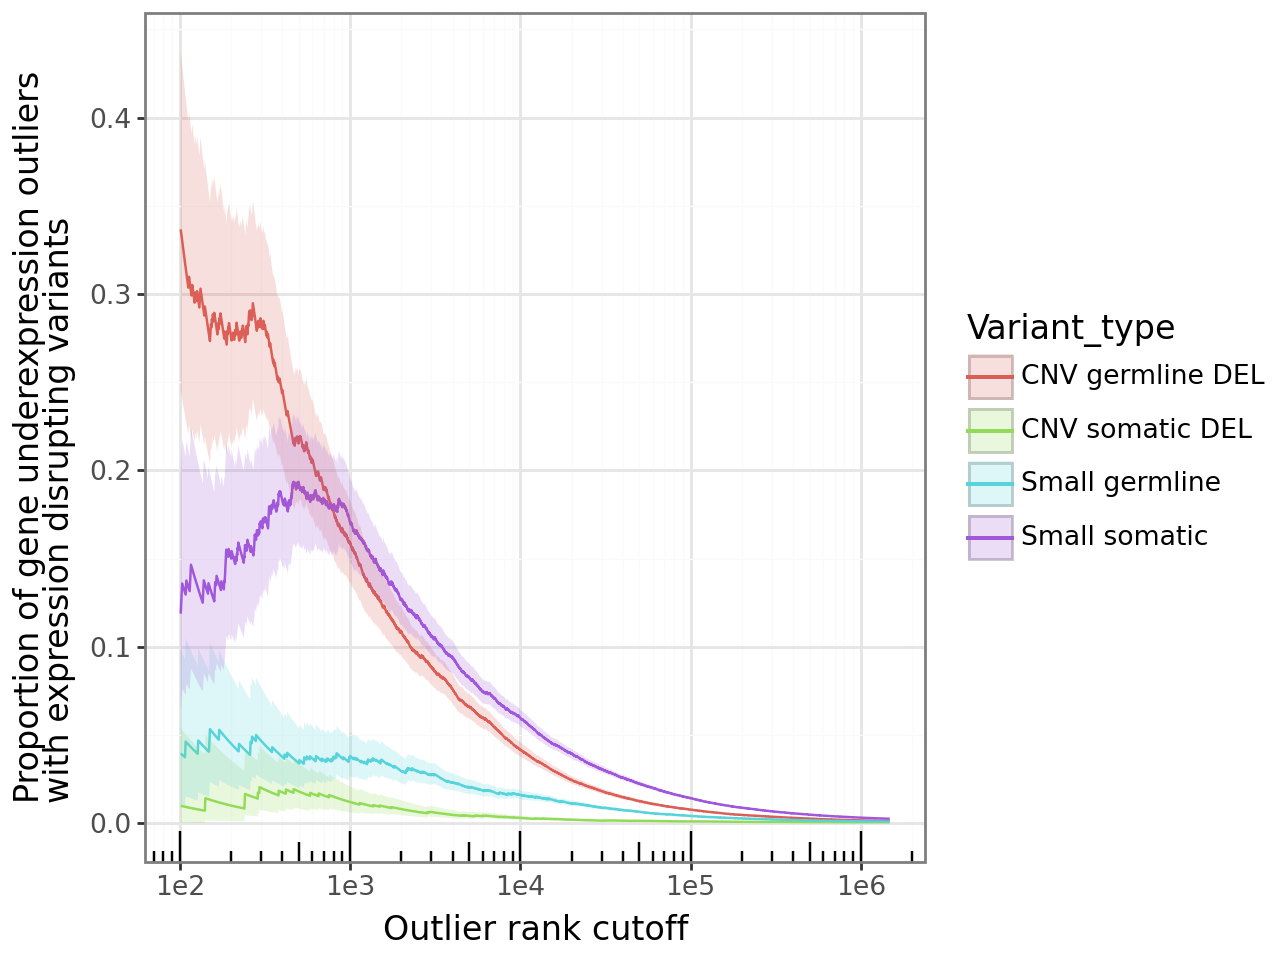

In [34]:

# plot_df = calculate_proportions(py_or_res_all, "VEP", "germline")
# plot_df["Variant_type"] = "Small germline"

# plot_df = plot_df.rename(columns = {f"underexpression_proportions_VEP_germline": "underexpression_proportions"})
# plot_df = plot_df.rename(columns = {f"underexpression_ci_max_VEP_germline": "underexpression_ci_max"})
# plot_df = plot_df.rename(columns = {f"underexpression_ci_min_VEP_germline": "underexpression_ci_min"})



# plot_df2 = calculate_proportions(py_or_res_all, "VEP", "somatic")
# plot_df2["Variant_type"] = "Small somatic"
# plot_df2 = plot_df2.rename(columns = {f"underexpression_proportions_VEP_somatic": "underexpression_proportions"})
# plot_df2 = plot_df2.rename(columns = {f"underexpression_ci_max_VEP_somatic": "underexpression_ci_max"})
# plot_df2 = plot_df2.rename(columns = {f"underexpression_ci_min_VEP_somatic": "underexpression_ci_min"})

# plot_df3 = calculate_proportions(py_or_res_all, "CNV", "somatic")
# plot_df3["Variant_type"] = "CNV somatic DEL"
# plot_df3 = plot_df3.rename(columns = {f"underexpression_proportions_CNV_somatic": "underexpression_proportions"})
# plot_df3 = plot_df3.rename(columns = {f"underexpression_ci_max_CNV_somatic": "underexpression_ci_max"})
# plot_df3 = plot_df3.rename(columns = {f"underexpression_ci_min_CNV_somatic": "underexpression_ci_min"})

# plot_df4 = calculate_proportions(py_or_res_all, "CNV", "germline")
# plot_df4["Variant_type"] = "CNV germline DEL"
# plot_df4 = plot_df4.rename(columns = {f"underexpression_proportions_CNV_germline": "underexpression_proportions"})
# plot_df4 = plot_df4.rename(columns = {f"underexpression_ci_max_CNV_germline": "underexpression_ci_max"})
# plot_df4 = plot_df4.rename(columns = {f"underexpression_ci_min_CNV_germline": "underexpression_ci_min"})



# plot_dt = pd.concat((plot_dt, plot_df3, plot_df4))


for expression_direction in ["underexpression"]:

    if expression_direction == "underexpression":
            plot_data = plot_dt[plot_dt["zScore"] < 0]
            CNV_label = "Deletion CNV"
            CNV_label = "AMP/DUP CNV"
    else:
        plot_data = plot_dt[plot_dt["zScore"] > 0]


    p = ( pn.ggplot(plot_data[(plot_data["Method"] == "OUTRIDER") & (plot_data[f"{expression_direction}_rank"] > 100) & 
                                    (plot_data[f"{expression_direction}_rank"] < 1e10)])
                
                # --- Line 1 (Deletion) ---
                # We map 'color' to a string label. Plotnine sees this as a category.
                + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                    y="underexpression_proportions", color="Variant_type")
                              ) 
                + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                        ymin="underexpression_ci_min", ymax="underexpression_ci_max", fill = "Variant_type"), 
                                alpha=0.2, outline_type='none')
                
            
                + pn.scale_x_log10()
                + pn.annotation_logticks(sides="b")
                + pn.labs(
                    y=f"Proportion of gene {expression_direction} outliers\nwith expression disrupting variants",
                    x="Outlier rank cutoff",
                    # title="Across all genes"
                )
                + pn.theme_bw(base_size=12)
    )

    # p.save(f"/home/a379i/Scripts/AberrantExpression/proportions_predisp_{expression_direction}_vep_cnv.png", width=6, height=4, dpi=300)

p

In [21]:
germline_sig.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [82]:
base_path = "/omics/odcf/analysis/hipo/hipo_021/GermlineAnalysis/data_object_master_germline/sequencing/whole_genome_sequencing/results_per_pid/"

df = pl.read_csv(f"{base_path}//H021-F9WBEY/germline_smallVariants.tumor.blood/v3.0.0/smallVariants_H021-F9WBEY.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df[df["POS"] == 155208082]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [84]:
smallest_columns = ["nct_pid", "gene_name", "geneID_short", "germline_chrom", "germline_POS",  "germline_REF", "germline_ALT", "germline_promoterAI", "germline_abexp_v1.1", "germline_IMPACT", "germline_Consequence", "germline_ClinVar_Pathogenicity", "germline_ACMG_Classification", "germline_CharGer_Classification", "somatic_REF", "somatic_ALT",  "somatic_promoterAI", "somatic_Consequence", "somatic_IMPACT", "somatic_abexp_v1.1", "zScore", "Oncotree Code", "Oncotree Text", "CNV", "Tumorzellgehalt (Bioinformatik)"]


germline_sig = py_or_res_all[(py_or_res_all["padjust_genes_of_interest"] <= 0.1) & (py_or_res_all["zScore"] <= 0) & (
    (py_or_res_all["germline_abexp_v1.1"] <= -0.1) | 
    (py_or_res_all["germline_promoterAI"] <= -0.1) |
    (py_or_res_all["germline_IMPACT"].str.contains("HIGH"))) ]


annotated_vars = (pl.scan_parquet(
                  "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet")
                  .filter((pl.col("#CHROM").is_in(germline_sig["germline_chrom"])) & (pl.col("POS").is_in(germline_sig["germline_POS"])))
                  .rename({"ACMG_Classification": "germline_ACMG_Classification", "CharGer_Classification": "germline_CharGer_Classification", "ClinVar_Pathogenicity": "germline_ClinVar_Pathogenicity"})
                  .collect(engine="streaming")
                 )

annotated_vars = annotated_vars.to_pandas().drop_duplicates(subset = ["#CHROM", "POS", "REF", "ALT"])


germline_sig = germline_sig.merge(annotated_vars, how="left", left_on=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])
# germline_sig.drop_duplicates(subset=["geneID_short", "sampleID_x"])


germline_sig = germline_sig.merge(df, how="left", left_on=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])
germline_sig.loc[
    germline_sig["germline_ACMG_Classification"].isna(), 
    ["germline_ClinVar_Pathogenicity", "germline_ACMG_Classification", "germline_CharGer_Classification"]
] = germline_sig.loc[
    germline_sig["germline_ACMG_Classification"].isna(), 
    ["ClinVar_Pathogenicity", "ACMG_Classification", "CharGer_Classification"]
].values


# germline_sig[smallest_columns]
germline_sig[germline_sig["geneID_short"].isin(AD_inheritence["geneID_short"])][smallest_columns]




Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [85]:
variant_coords = [
    "germline_chrom",
    "germline_POS",
    "germline_REF",
    "germline_ALT",
    "nct_pid"
]
germline_sig = germline_sig.drop_duplicates(subset = variant_coords)
germline_sig[germline_sig["geneID_short"].isin(AD_inheritence["geneID_short"])][smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_underexpression_tier1_vus.tsv", sep="\t", index=None)
germline_sig[germline_sig["geneID_short"].isin(dresden_dt["geneID_short"])][smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_underexpression_tier2_vus.tsv", sep="\t", index=None)


# protein underexpression

In [92]:
dresden_somatic = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/somatic/somatic_aggregated_predisp_cgc.parquet")
                   .filter((pl.col("somatic_abexp_v1.1") <= -0.1) | (pl.col("somatic_promoterAI") <= -0.1) | (pl.col("somatic_IMPACT").str.contains("HIGH")) | (pl.col("somatic_Consequence").str.contains("missense")))
                    .collect(engine="streaming")
                    
                  ).to_pandas()
# dresden_somatic

                           


In [93]:
dresden_germline = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/germline/germline_aggregated_predisp_cgc.parquet")
                   .filter((pl.col("germline_abexp_v1.1") <= -0.1) | (pl.col("germline_promoterAI") <= -0.1) | (pl.col("germline_IMPACT").str.contains("HIGH")) | (pl.col("germline_Consequence").str.contains("missense")))
                    .collect(engine="streaming")        
                  ).to_pandas()
# dresden_germline

                           


In [94]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_interesting_genes_padjust_cnv.parquet").filter((pl.col("geneID_short").is_in(genes_of_interest["geneID_short"]))).collect(engine="streaming").to_pandas()
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID_short", how="left")
pr_res_all = pd.merge(pr_res_all, sa[["pid", "Diag", "seq_type", "Oncotree Code", "Oncotree Text", "nct_pid", "Tumorzellgehalt (Bioinformatik)"]], left_on="sampleID", right_on="pid")
pr_res_all["Method"] = "PROTRIDER"


In [95]:
pr_res_all = pr_res_all.merge(dresden_germline[[ "Gene", "#CHROM", "seqnames", "POS", "REF", "ALT", "germline_abexp_v1.1", "germline_IMPACT", "PID", "germline_promoterAI", "germline_Consequence",]], left_on=["sampleID", "geneID_short"], right_on=["PID", "Gene"], how="left").rename(columns={ "POS": "germline_POS", "REF": "germline_REF", "ALT": "germline_ALT"})

pr_res_all = pr_res_all.merge(dresden_somatic[[ "Gene", "#CHROM", "seqnames", "POS", "REF", "ALT", "somatic_abexp_v1.1", "somatic_IMPACT", "PID", "somatic_promoterAI", "somatic_Consequence"]], left_on=["sampleID", "geneID_short"], right_on=["PID", "Gene"], how="left").rename(columns={"POS": "somatic_POS", "REF": "somatic_REF", "ALT": "somatic_ALT", "#CHROM_x": "germline_chrom", "#CHROM_y": "somatic_chrom"})




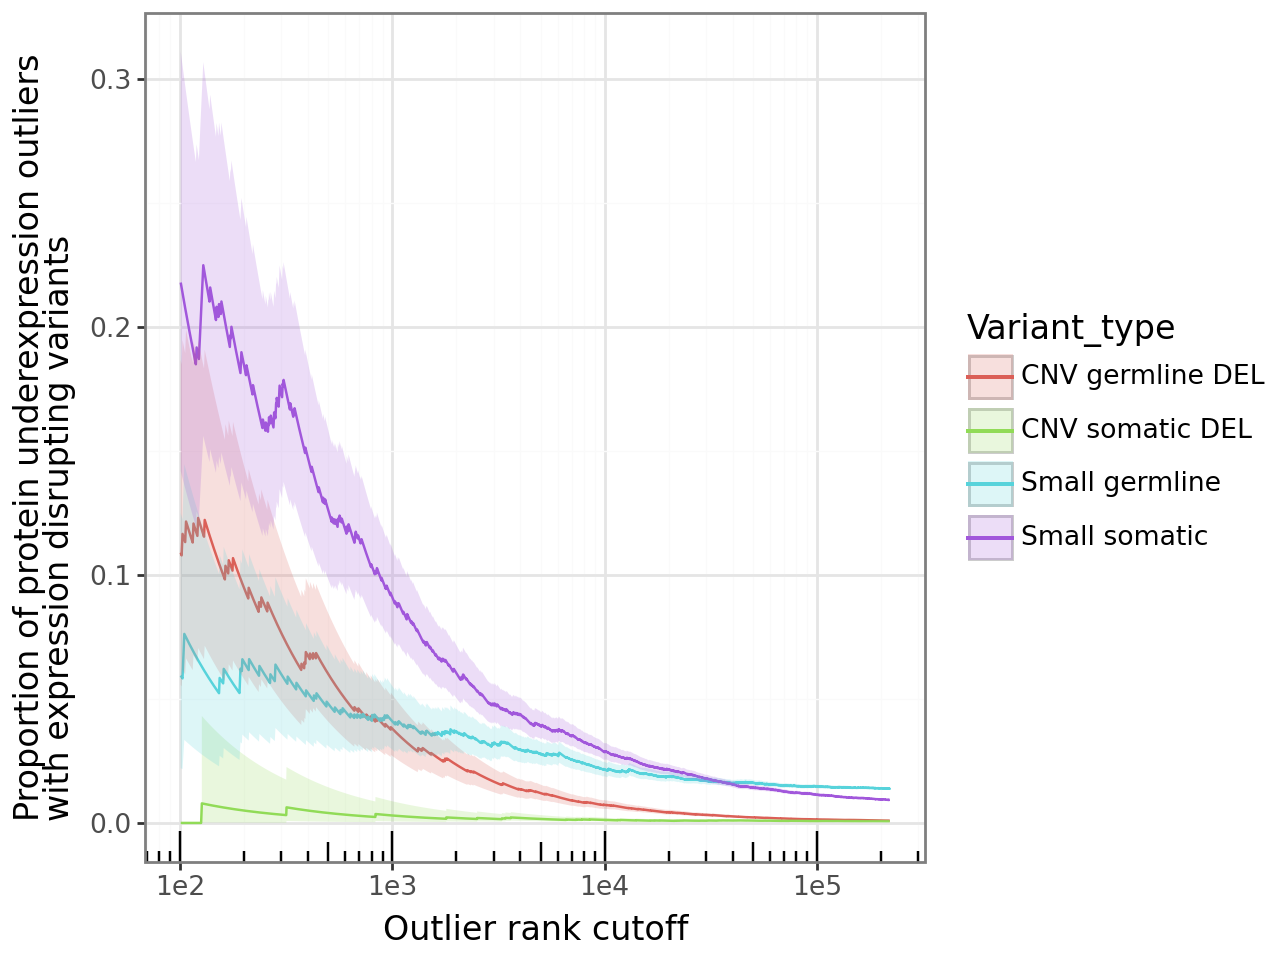

In [23]:

plot_df = calculate_proportions(pr_res_all, "VEP", "germline", omic_type = "protein")
plot_df["Variant_type"] = "Small germline"

plot_df = plot_df.rename(columns = {f"underexpression_proportions_VEP_germline": "underexpression_proportions"})
plot_df = plot_df.rename(columns = {f"underexpression_ci_max_VEP_germline": "underexpression_ci_max"})
plot_df = plot_df.rename(columns = {f"underexpression_ci_min_VEP_germline": "underexpression_ci_min"})



plot_df2 = calculate_proportions(pr_res_all, "VEP", "somatic", omic_type = "protein")
plot_df2["Variant_type"] = "Small somatic"
plot_df2 = plot_df2.rename(columns = {f"underexpression_proportions_VEP_somatic": "underexpression_proportions"})
plot_df2 = plot_df2.rename(columns = {f"underexpression_ci_max_VEP_somatic": "underexpression_ci_max"})
plot_df2 = plot_df2.rename(columns = {f"underexpression_ci_min_VEP_somatic": "underexpression_ci_min"})

plot_df3 = calculate_proportions(pr_res_all, "CNV", "somatic", omic_type = "protein")
plot_df3["Variant_type"] = "CNV somatic DEL"
plot_df3 = plot_df3.rename(columns = {f"underexpression_proportions_CNV_somatic": "underexpression_proportions"})
plot_df3 = plot_df3.rename(columns = {f"underexpression_ci_max_CNV_somatic": "underexpression_ci_max"})
plot_df3 = plot_df3.rename(columns = {f"underexpression_ci_min_CNV_somatic": "underexpression_ci_min"})

plot_df4 = calculate_proportions(pr_res_all, "CNV", "germline", omic_type = "protein")
plot_df4["Variant_type"] = "CNV germline DEL"
plot_df4 = plot_df4.rename(columns = {f"underexpression_proportions_CNV_germline": "underexpression_proportions"})
plot_df4 = plot_df4.rename(columns = {f"underexpression_ci_max_CNV_germline": "underexpression_ci_max"})
plot_df4 = plot_df4.rename(columns = {f"underexpression_ci_min_CNV_germline": "underexpression_ci_min"})



plot_dt = pd.concat((plot_df, plot_df2, plot_df3, plot_df4))


for expression_direction in ["underexpression"]:

    if expression_direction == "underexpression":
            plot_data = plot_dt[plot_dt["zScore"] < 0]
            CNV_label = "Deletion CNV"
            CNV_label = "AMP/DUP CNV"
    else:
        plot_data = plot_dt[plot_dt["zScore"] > 0]


    p_protein = ( pn.ggplot(plot_data[(plot_data[f"{expression_direction}_rank"] > 100) & 
                                    (plot_data[f"{expression_direction}_rank"] < 1e10)])
                
                # --- Line 1 (Deletion) ---
                # We map 'color' to a string label. Plotnine sees this as a category.
                + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                    y="underexpression_proportions", color="Variant_type")
                              ) 
                + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                        ymin="underexpression_ci_min", ymax="underexpression_ci_max", fill = "Variant_type"), 
                                alpha=0.2, outline_type='none')
                
            
                + pn.scale_x_log10()
                + pn.annotation_logticks(sides="b")
                + pn.labs(
                    y=f"Proportion of protein {expression_direction} outliers\nwith expression disrupting variants",
                    x="Outlier rank cutoff",
                    # title="Across all genes"
                )
                + pn.theme_bw(base_size=12)
    )

    # p.save(f"/home/a379i/Scripts/AberrantExpression/proportions_predisp_{expression_direction}_vep_cnv.png", width=6, height=4, dpi=300)

p_protein

In [46]:
YTV8N8_metastasis

'metastasis'

In [94]:
all_dfs["sampleID"].unique()


<ArrowStringArray>
[ 'XBLS3R', '2UBHKNR',  '7CCGJ4',  'M2BK2Y',  'C2AL3T',  'RBZMVF', 'WNBGXXT',
  '22JTPS',  'WEZF97',  'BXZS35',  'VVEHNT',  '3582P3',  'RXLJ7X',  'QY2Q95',
  'NPY8VX']
Length: 15, dtype: str

In [96]:
smallest_columns = ["nct_pid", "proteinID", "geneID_short", "germline_chrom", "germline_POS",  "germline_REF", "germline_ALT", "germline_ClinVar_Pathogenicity", "germline_ACMG_Classification", "germline_CharGer_Classification", "somatic_REF", "somatic_ALT", "germline_promoterAI", "germline_abexp_v1.1", "germline_IMPACT", "germline_Consequence", "somatic_promoterAI", "somatic_Consequence", "somatic_IMPACT", "somatic_abexp_v1.1", "zScore", "Oncotree Code", "Oncotree Text", "ROLE_IN_CANCER", "CNV", "Tumorzellgehalt (Bioinformatik)"]


pr_germline_sig = pr_res_all[(pr_res_all["padjust_genes_of_interest"] <= 0.1) & (pr_res_all["zScore"] <= 0) & (
    (pr_res_all["germline_abexp_v1.1"] <= -0.1) | 
    (pr_res_all["germline_promoterAI"] <= -0.1) |
    (pr_res_all["germline_Consequence"].str.contains("missense")) |
    (pr_res_all["germline_IMPACT"].str.contains("HIGH"))) ]

print(pr_germline_sig.shape, "all protein res")

annotated_vars = (pl.scan_parquet(
                  "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet")
                  .filter((pl.col("#CHROM").is_in(germline_sig["germline_chrom"])) & (pl.col("POS").is_in(germline_sig["germline_POS"])))
                  .rename({"ACMG_Classification": "germline_ACMG_Classification", "CharGer_Classification": "germline_CharGer_Classification", "ClinVar_Pathogenicity": "germline_ClinVar_Pathogenicity"})
                  .collect(engine="streaming")
                 )

annotated_vars = annotated_vars.to_pandas().drop_duplicates(subset = ["#CHROM", "POS", "REF", "ALT"])


pr_germline_sig = pr_germline_sig.merge(annotated_vars, how="left", left_on=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])


base_path = "/omics/odcf/analysis/hipo/hipo_021/GermlineAnalysis/data_object_master_germline/sequencing/whole_genome_sequencing/results_per_pid/"

pids = pr_germline_sig["nct_pid"].unique()




all_dfs = []


for pid in pids:
    try:
        sample_path = f"H021-{pid.split("_")[0]}/germline_smallVariants.{pid.split("_")[1]}.blood/v5/clinvar_2023-09/smallVariants_H021-{pid.split("_")[0]}.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
        df = pl.read_csv(f"{base_path}/{sample_path}",
                         separator="\t", comment_prefix="##",  schema_overrides={
                                            "QUAL": pl.String,
                                            "#CHROM": pl.String,
                                            "RNA_VARIANT_AF": pl.Float64,
                                        }, 
                            null_values=["NA", "."],
        ).to_pandas()
        df["sampleID"] = pid.split("_")[0]
        all_dfs.append(df)
    except:
        continue

all_dfs = pd.concat(all_dfs)



sample_path = "/H021-RXLJ7X/germline_smallVariants.metastasis05.buffy_coat02/v3.3.1/smallVariants_H021-RXLJ7X.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "RXLJ7X"
all_dfs = pd.concat((all_dfs, df))

sample_path = "/H021-QY2Q95/germline_smallVariants.metastasis.buffy_coat/v3.0.0/smallVariants_H021-QY2Q95.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "QY2Q95"
all_dfs = pd.concat((all_dfs, df))

sample_path = "/H021-5WWWE7/germline_smallVariants.tumor02.blood/v4.0.2/smallVariants_H021-5WWWE7.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "5WWWE7"
all_dfs = pd.concat((all_dfs, df))

all_dfs = all_dfs.drop_duplicates(subset=["#CHROM", "POS", "REF", "ALT"])
# not in wgs YTV8N8_metastasis

sample_path = "/H021-NPY8VX/germline_smallVariants.metastasis.blood/v4.0.2/smallVariants_H021-NPY8VX.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "NPY8VX"
all_dfs = pd.concat((all_dfs, df))


base_path = "/omics/odcf/analysis/hipo/hipo_021/GermlineAnalysis/data_object_master_germline/sequencing/exon_sequencing/results_per_pid/"

sample_path = "H021-YTV8N8/germline_smallVariants.metastasis.blood/v3.0.0/smallVariants_H021-YTV8N8.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "YTV8N8"
all_dfs = pd.concat((all_dfs, df))


sample_path = "/H021-JA26GW/germline_smallVariants.tumor.buffy_coat/v3.0.0/smallVariants_H021-JA26GW.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "JA26GW"
all_dfs = pd.concat((all_dfs, df))



sample_path = "/H021-4F7QS3/germline_smallVariants.tumor.blood/v3.0.0/smallVariants_H021-4F7QS3.clean_annotated.rare.VEP.CharGer.TiNDA.rare_germline.vcf"
df = pl.read_csv(f"{base_path}/{sample_path}",
                 separator="\t", comment_prefix="##",  schema_overrides={
                                    "QUAL": pl.String,
                                    "#CHROM": pl.String,
                                    "RNA_VARIANT_AF": pl.Float64,
                                }, 
                    null_values=["NA", "."],
).to_pandas()
df["sampleID"] = "4F7QS3"
all_dfs = pd.concat((all_dfs, df))



print(pr_germline_sig[pr_germline_sig["geneID_short"].isin(AD_inheritence["geneID_short"])][smallest_columns].shape)


pr_germline_sig = pr_germline_sig.merge(all_dfs, how="left", left_on=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])
pr_germline_sig.loc[
    pr_germline_sig["germline_ACMG_Classification"].isna(), 
    ["germline_ClinVar_Pathogenicity", "germline_ACMG_Classification", "germline_CharGer_Classification"]
] = pr_germline_sig.loc[
    pr_germline_sig["germline_ACMG_Classification"].isna(), 
    ["ClinVar_Pathogenicity", "ACMG_Classification", "CharGer_Classification"]
].values


# final_gene_expression[final_gene_expression["HUGO_Symbol"].isin(AD_inheritence["Approved symbol (HGNC)"])][smallest_columns]
pr_germline_sig[smallest_columns]
# pr_germline_sig[pr_germline_sig["geneID_short_x"].isin(AD_inheritence["geneID_short"])].drop_duplicates(subset=["geneID_short_x", "sampleID"])
# pr_germline_sig.drop_duplicates(subset=["geneID_short_x", "sampleID"])


variant_coords = [
    "germline_chrom",
    "germline_POS",
    "germline_REF",
    "germline_ALT",
    "nct_pid"
]

pr_germline_sig[pr_germline_sig["geneID_short"].isin(AD_inheritence["geneID_short"])][smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/protein_underexpression_tier1_vus.tsv", sep="\t", index=None)
pr_germline_sig[pr_germline_sig["geneID_short"].isin(dresden_dt["geneID_short"])][smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/protein_underexpression_tier2_vus.tsv", sep="\t", index=None)



(30, 77) all protein res
(14, 26)


In [100]:
pr_germline_sig[pr_germline_sig["geneID_short"].isin(dresden_dt["geneID_short"])][smallest_columns]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Aberrant Splicing

In [27]:
needed_cols = ["#CHROM", "POS", "REF", "ALT", "germline_Consequence", "germline_IMPACT",  "SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL", "PID",  "SYMBOL"]


dresden_germline_splice = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/germline/germline_aggregated_predisp_cgc.parquet")
                    .select(needed_cols)
                    .collect(engine="streaming")        
                  ).to_pandas()
# dresden_germline


                           
valid_positions = (
    dresden_germline_splice["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)
dresden_germline_splice["#CHROM"] = "chr" + dresden_germline_splice["#CHROM"] 


absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_cgc_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_end").is_in(valid_positions)))
        .collect(engine="streaming")
      ).to_pandas()
absplice_predisp.shape




merged_vars = dresden_germline_splice.merge(absplice_predisp, left_on=["#CHROM", "POS", "REF", "ALT"], right_on=["chrom", "hg19_end", "ref", "alt"], how="left")
cols_to_fix = [
    "AbSplice2_max", "pangolin_score", 
    "SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL"
]

for col in cols_to_fix:
    merged_vars[col] = pd.to_numeric(merged_vars[col], errors='coerce')


merged_vars["germline_max_spliceai_score"] = merged_vars[["SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL"
]].max(axis=1)
merged_vars = merged_vars.rename(columns = {"max_spliceai_score": "germline_max_spliceai_score"})
    
all_vars_splice = merged_vars[
    (merged_vars["AbSplice2_max"] >= 0.05) | 
    (merged_vars["pangolin_score"] >= 0.2) |
    (merged_vars["germline_Consequence"].isin(["splice_acceptor_variant", "splice_donor_variant"])) | 
    (merged_vars["SpliceAI_pred_DS_AL"] >= 0.2) | 
    (merged_vars["SpliceAI_pred_DS_AG"] >= 0.2) | 
    (merged_vars["SpliceAI_pred_DS_DG"] >= 0.2) | 
    (merged_vars["SpliceAI_pred_DS_DL"] >= 0.2)
    ]

all_vars_splice = all_vars_splice.rename(columns={"AbSplice2_max": "germline_AbSplice2_max", "pangolin_score": "germline_pangolin_score",
                                                 "POS": "germline_POS", "REF": "germline_REF",
                                                  "ALT": "germline_ALT", "#CHROM": "germline_chrom",
                                                 "ACMG_Classification": "germline_ACMG_Classification", "CharGer_Classification": "germline_CharGer_Classification", "ClinVar_Pathogenicity": "germline_ClinVar_Pathogenicity"})

# all_vars_splice["germline_chrom"] = "chr" + all_vars_splice["germline_chrom"]

annotated_vars = (pl.scan_parquet(
                  "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet")
                  .filter((pl.col("POS").is_in(all_vars_splice["germline_POS"])))
                  .rename({"ACMG_Classification": "germline_ACMG_Classification", "CharGer_Classification": "germline_CharGer_Classification", "ClinVar_Pathogenicity": "germline_ClinVar_Pathogenicity"})
                  .collect(engine="streaming")
                 )

annotated_vars = annotated_vars.to_pandas().drop_duplicates(subset = ["#CHROM", "POS", "REF", "ALT"])
annotated_vars["#CHROM"] = "chr" + annotated_vars["#CHROM"]


all_vars_splice = all_vars_splice.merge(annotated_vars, how="left", left_on=["germline_chrom", "germline_POS", "germline_REF", "germline_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])



print(len(all_vars_splice))



19004


In [28]:
needed_cols = ["#CHROM", "POS", "REF", "ALT", "somatic_Consequence", "somatic_IMPACT",  "SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL", "PID", "SYMBOL"]

dresden_somatic_splice = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/dresden_annotations/somatic/somatic_aggregated_predisp_cgc.parquet")
                    .select(needed_cols)
                    .collect(engine="streaming")
                    
                  ).to_pandas()
# dresden_somatic
                          
valid_positions = (
    dresden_somatic_splice["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)
dresden_somatic_splice["#CHROM"] = "chr" + dresden_somatic_splice["#CHROM"] 


absplice_predisp_somatic = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_cgc_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_end").is_in(valid_positions)))
        .collect(engine="streaming")
      ).to_pandas()
absplice_predisp_somatic.shape






merged_vars_somatic = dresden_somatic_splice.merge(absplice_predisp_somatic, left_on=["#CHROM", "POS", "REF", "ALT"], right_on=["chrom", "hg19_end", "ref", "alt"], how="left")


cols_to_fix = [
    "AbSplice2_max", "pangolin_score", 
    "SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL"
]

for col in cols_to_fix:
    merged_vars_somatic[col] = pd.to_numeric(merged_vars_somatic[col], errors='coerce')

merged_vars_somatic["somatic_max_spliceai_score"] = merged_vars_somatic[
    ["SpliceAI_pred_DS_AL", "SpliceAI_pred_DS_AG", 
    "SpliceAI_pred_DS_DG", "SpliceAI_pred_DS_DL"
]
].max(axis=1)
merged_vars_somatic = merged_vars_somatic.rename(columns = {"max_spliceai_score": "somatic_max_spliceai_score"})

all_vars_splice_somatic = merged_vars_somatic[
    (merged_vars_somatic["AbSplice2_max"] >= 0.05) | 
    (merged_vars_somatic["pangolin_score"] >= 0.2) |
    (merged_vars_somatic["somatic_Consequence"].isin(["splice_acceptor_variant", "splice_donor_variant"])) | 
    (merged_vars_somatic["SpliceAI_pred_DS_AL"] >= 0.2) | 
    (merged_vars_somatic["SpliceAI_pred_DS_AG"] >= 0.2) | 
    (merged_vars_somatic["SpliceAI_pred_DS_DG"] >= 0.2) | 
    (merged_vars_somatic["SpliceAI_pred_DS_DL"] >= 0.2)
    ]

all_vars_splice_somatic = all_vars_splice_somatic.rename(columns={"AbSplice2_max": "somatic_AbSplice2_max", "pangolin_score": "somatic_pangolin_score",
                                                    "POS": "somatic_POS", "REF": "somatic_REF",
                                                  "ALT": "somatic_ALT", "#CHROM": "somatic_chrom",
                                                 "ACMG_Classification": "somatic_ACMG_Classification", "CharGer_Classification": "somatic_CharGer_Classification", "ClinVar_Pathogenicity": "somatic_ClinVar_Pathogenicity"})

# all_vars_splice["germline_chrom"] = "chr" + all_vars_splice["germline_chrom"]

annotated_vars = (pl.scan_parquet(
                  "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet")
                  .filter((pl.col("POS").is_in(all_vars_splice_somatic["somatic_POS"])))
                  .rename({"ACMG_Classification": "somatic_ACMG_Classification", "CharGer_Classification": "somatic_CharGer_Classification", "ClinVar_Pathogenicity": "somatic_ClinVar_Pathogenicity"})
                  .collect(engine="streaming")
                 )

annotated_vars = annotated_vars.to_pandas().drop_duplicates(subset = ["#CHROM", "POS", "REF", "ALT"])
annotated_vars["#CHROM"] = "chr" + annotated_vars["#CHROM"]


all_vars_splice_somatic = all_vars_splice_somatic.merge(annotated_vars, how="left", left_on=["somatic_chrom", "somatic_POS", "somatic_REF", "somatic_ALT"], right_on = ["#CHROM", "POS", "REF", "ALT"])




                           


In [57]:

all_res = []

for cohort in sa[sa["Diag"] != "Unstranded_data"]["Diag"].unique():
    
    fr_res_new =( pl.scan_csv(f"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/{cohort}/results_per_junction.tsv", 
                                schema_overrides={
                                    "deltaPsi": pl.Float64,
                                    "seqnames": pl.String,
                                }, 
                                null_values=["NA"],
                                 separator="\t")
                    .select("sampleID", "hgncSymbol", "pValue", "padjust", 'seqnames', 'start', 'end', 'strand', 'deltaPsi', 'counts', 'totalCounts', 'nonsplitCounts')
                    .filter((pl.col("padjust") <= 0.1) & (abs(pl.col("deltaPsi")) >= 0.15))
                    .collect(engine="streaming")
                    ).rename({"start": "junction_start", "end": "junction_end"}).to_pandas()
    # fr_res_new[(fr_res_new["padjust"] <= 0.05) & (fr_res_new["padjust_Genes_to_test_on_all_samples"].notna())]
    fr_res_new = fr_res_new.merge(sa, left_on="sampleID", right_on="pid")
    
    # fr_res_new["key"] = fr_res_new["sampleID"] +  "." + fr_res_new["nct_pid"].str.split("_").str[1]
    predisp_absplice = fr_res_new.merge(all_vars_splice, left_on=["sampleID", "hgncSymbol"], right_on=["PID", "SYMBOL"], how="left")
    predisp_absplice = predisp_absplice.merge(all_vars_splice_somatic, left_on=["sampleID_x", "hgncSymbol"], right_on=["PID", "SYMBOL"], how="left")
    all_res.append(predisp_absplice)
all_res = pd.concat(all_res)



In [58]:
def join_types(row):
    parts = [p for p in [row["Type_x"], row["Type_y"]] if p != ""]
    return " | ".join(parts) if parts else "No CNV"



# cnv_germline = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_exploded_filtered.tsv", sep="\t")
# cnv_germline = cnv_germline[cnv_germline["Confidence"] == "HIGH"]

# cnv = ( pl.scan_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_exploded_filtered.tsv", separator="\t", infer_schema_length=1000000)
#         .filter(pl.col("Type") != "CNN")
#         .collect(engine="streaming")
#       ).to_pandas()

# cnv = cnv[((cnv["Type"] == "AMP") | (cnv["Type"] == "HDEL")) & (cnv["width"] >= 10000)]


# cnv = cnv.merge(gene_annot_dt[["geneID_short", "gene_name"]], left_on="Gene", right_on="gene_name")
# cnv_germline = cnv_germline.merge(gene_annot_dt[["geneID_short", "gene_name"]], left_on="Gene", right_on="gene_name")

# cnv = cnv.drop_duplicates(subset=["sampleID", "geneID_short"])
# cnv_germline = cnv_germline.drop_duplicates(subset=["sampleID", "geneID_short"])



all_res = pd.merge(
    all_res, 
    cnv[["Type", "gene_name", "sampleID"]], 
    left_on=['hgncSymbol', 'sampleID'],
    right_on=["gene_name", "sampleID"],
    how='left'
)

all_res = pd.merge(
    all_res, 
    cnv_germline[["Type", "gene_name", "sampleID"]], 
    left_on=['hgncSymbol', 'sampleID'], 
    right_on=["gene_name", "sampleID"],
    how='left'
)
# Replace NaN with empty strings before concatenating


all_res["Type_x"] = [f"Somatic_{x}" if pd.notna(x) and x != "" else "" for x in all_res["Type_x"]]

# Clean Germline labels
all_res["Type_y"] = [f"Germline_{y}" if pd.notna(y) and y != "" else "" for y in all_res["Type_y"]]


all_res["CNV"] = all_res.apply(join_types, axis=1)

In [63]:
#all_res_splice.drop_duplicates(subset=["sampleID", "hgncSymbol", 'junction_start', 'junction_end'])
smallest_columns = ["nct_pid", "hgncSymbol", "junction_start" ,"junction_end", "deltaPsi", "germline_max_spliceai_score", "germline_pangolin_score", "germline_AbSplice2_max", "germline_chrom", "germline_POS",  
                    "germline_REF", "germline_ALT", "germline_ClinVar_Pathogenicity", "germline_ACMG_Classification", "germline_CharGer_Classification", "germline_IMPACT", "germline_Consequence",
                    "somatic_REF", "somatic_ALT", "somatic_IMPACT", "somatic_max_spliceai_score", "somatic_pangolin_score", "somatic_AbSplice2_max", "CNV",
                    "Oncotree Code", "hgncSymbol", "Oncotree Text", "Tumorzellgehalt (Bioinformatik)", 
                  "counts", "totalCounts", "nonsplitCounts", ]

all_res[(all_res["germline_chrom"].notna()) & 
    (all_res["totalCounts"] >= 10) & (all_res["germline_POS"] >= all_res["junction_start"] - 500) & (all_res["germline_POS"] <= all_res["junction_end"] + 500) &
    (all_res["hgncSymbol"].isin(AD_inheritence["Approved symbol (HGNC)"]))].drop_duplicates(subset=["nct_pid", "junction_start", "junction_end", "germline_chrom", "germline_POS", "germline_REF", "germline_ALT"])[smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_splicing_tier1_vus.tsv", sep="\t", index=None)

all_res[(all_res["germline_chrom"].notna()) & 
    (all_res["totalCounts"] >= 10) & (all_res["germline_POS"] >= all_res["junction_start"] - 500) & (all_res["germline_POS"] <= all_res["junction_end"] + 500) &
    (all_res["hgncSymbol"].isin(dresden_dt["gene_name"]))].drop_duplicates(subset=["nct_pid", "junction_start", "junction_end", "germline_chrom", "germline_POS", "germline_REF", "germline_ALT"])[smallest_columns].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202606/gene_splicing_tier2_vus.tsv", sep="\t", index=None)

In [79]:
all_res_splice[(all_res_splice["hgncSymbol"].isin(AD_inheritence["Approved symbol (HGNC)"]))].drop_duplicates(subset=["sampleID", "hgncSymbol", 'junction_start', 'junction_end'])

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
